## Downloading the BraTS dataset from the Medical Segmentation Decathlon

In [34]:
# Imports
import os
from monai.apps import DecathlonDataset
from monai.transforms import Compose, Orientationd, LoadImaged, EnsureChannelFirstD

import torch
import matplotlib.pyplot as plt

In [14]:
# Ensure the directory exists
root_dir = "../datasource"
if not os.path.exists(root_dir):
    os.makedirs(root_dir)
    print("Directory " , root_dir , " Created ")

else:
    print("Directory " , root_dir , " already exists")

Directory  ../data  already exists


In [15]:
# Transformations setup
"""
Set up a transformation pipeline that uses dictionaries to:
- Load images
- Ensures that the images (H, W, D) meet the Deep Learning architectures of (C, H, W, D)
- Enables right spatial interpretation for later AR Visualization (Right, Anterior, Superior)
"""
my_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstD(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
])

In [16]:
# Start the download / loading process
dataset = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    section="training",
    transform=my_transforms,
    download=True,
)

2026-01-25 19:09:58,655 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-01-25 19:09:58,655 - INFO - File exists: ../data/Task01_BrainTumour.tar, skipped downloading.
2026-01-25 19:09:58,656 - INFO - Non-empty folder exists in ../data/Task01_BrainTumour, skipped extracting.


Loading dataset: 100%|██████████| 388/388 [01:21<00:00,  4.77it/s]


## Inspecting the Dataset

In [17]:
len(dataset)

388

In [18]:
sample = dataset[0]
sample.keys()

dict_keys(['image', 'label'])

In [21]:
print(sample['image'].shape)
print(sample['label'].shape)

torch.Size([4, 240, 240, 155])
torch.Size([1, 240, 240, 155])


In [24]:
print(sample['image'].dtype)
print(sample['label'].dtype)

torch.float32
torch.float32


In [27]:
torch.unique(sample['label'])

metatensor([0., 1., 2., 3.])

In [28]:
sample['image'].meta

{'sizeof_hdr': array(348, dtype=int32),
 'extents': array(0, dtype=int32),
 'session_error': array(0, dtype=int16),
 'dim_info': array(0, dtype=uint8),
 'dim': array([  4, 240, 240, 155,   4,   1,   1,   1], dtype=int16),
 'intent_p1': array(0., dtype=float32),
 'intent_p2': array(0., dtype=float32),
 'intent_p3': array(0., dtype=float32),
 'intent_code': array(0, dtype=int16),
 'datatype': array(16, dtype=int16),
 'bitpix': array(32, dtype=int16),
 'slice_start': array(0, dtype=int16),
 'pixdim': array([1., 1., 1., 1., 1., 0., 0., 0.], dtype=float32),
 'vox_offset': array(0., dtype=float32),
 'scl_slope': array(nan, dtype=float32),
 'scl_inter': array(nan, dtype=float32),
 'slice_end': array(0, dtype=int16),
 'slice_code': array(0, dtype=uint8),
 'xyzt_units': array(10, dtype=uint8),
 'cal_max': array(0., dtype=float32),
 'cal_min': array(0., dtype=float32),
 'slice_duration': array(0., dtype=float32),
 'toffset': array(0., dtype=float32),
 'glmax': array(0, dtype=int32),
 'glmin': ar

### Dataset Audit
- Images are 4-channel multimodal MRI
- Labels are single-channel categorical masks
- All volumes are reoriented to RAS (Right Anterior Superior)
- Voxel spacing is isotropic (1 x 1 x 1 x mm)

In [33]:
"""
Mapping of indexes to their semantic meanings
0 - Background (Healthy tissue)
1 - Non-enhancing tumour core
2 - Peritumoral edema
3 - Enhanced tumor
"""
labels, counts = torch.unique(sample['label'], return_counts=True)

for count, label in zip(counts, labels):
    print("Label %s has %d count" % (label, count))

Label metatensor(0.) has 8835339 count
Label metatensor(1.) has 33130 count
Label metatensor(2.) has 12627 count
Label metatensor(3.) has 46904 count


In [39]:
img = sample['image'][0]
label = sample['label'][0]

z = img.shape[-1] // 2

Text(0.5, 1.0, 'MRI Slice')

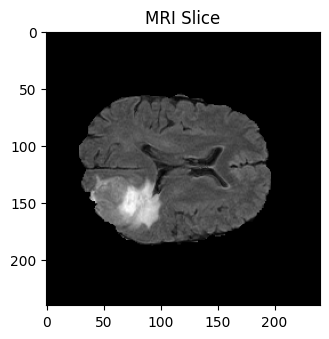

In [40]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)

plt.imshow(img[:, :, z], cmap="gray")
plt.title("MRI Slice")

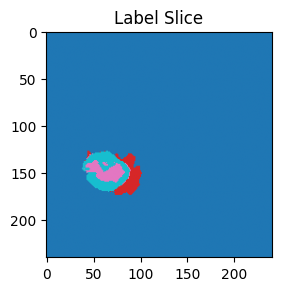

In [41]:
plt.subplot(1, 2, 2)
plt.imshow(label[:, :, z], cmap="tab10")
plt.title("Label Slice")
plt.show()